# Model Explainability

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

 Load Final Model

In [15]:
final_model = joblib.load(
    "../Models/final_random_forest_model.joblib"
)

feature_columns = joblib.load(
    "../Models/feature_columns.joblib"
)

print("Model loaded successfully.")
print("Number of features:", len(feature_columns))

Model loaded successfully.
Number of features: 17


Dataset Loading

In [16]:
data = pd.read_csv(
    "../Data/Processed/solar_model_data.csv"
)

data["time_utc"] = pd.to_datetime(
    data["time_utc"],
    utc=True
)

data["time_sl"] = pd.to_datetime(
    data["time_sl"]
)

data = data.sort_values(
    ["time_utc", "district"]
).reset_index(drop=True)

print("Dataset shape:", data.shape)

Dataset shape: (227218, 21)


Recreate Test Set

In [17]:
unique_times = (
    data["time_utc"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

validation_end = int(
    len(unique_times) * 0.85
)

validation_last_time = unique_times.iloc[
    validation_end - 1
]

test_data = data[
    data["time_utc"] > validation_last_time
].copy()

X_test = test_data[
    feature_columns
]

y_test = test_data["P"]

print("Test rows:", len(test_data))
print("X_test shape:", X_test.shape)
print(
    "Test period:",
    test_data["time_sl"].min(),
    "to",
    test_data["time_sl"].max()
)

Test rows: 33522
X_test shape: (33522, 17)
Test period: 2023-09-17 07:30:00+05:30 to 2023-12-31 18:30:00+05:30


Verify Final Model

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

predictions = final_model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 4))

MAE: 58.309
MSE: 7880.729
RMSE: 88.773
R²: 0.8197


Random Forest Feature Importance

In [19]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,hour_cos,0.635308
1,global_tilted_irradiance,0.236519
2,diffuse_radiation,0.032510
3,gti_lag_1,0.023835
4,relative_humidity_2m,0.018527
5,day_of_year_cos,0.009819
6,day_of_year_sin,0.008814
7,precipitation,0.006007
8,wind_speed_10m,0.005118
9,temperature_2m,0.004857


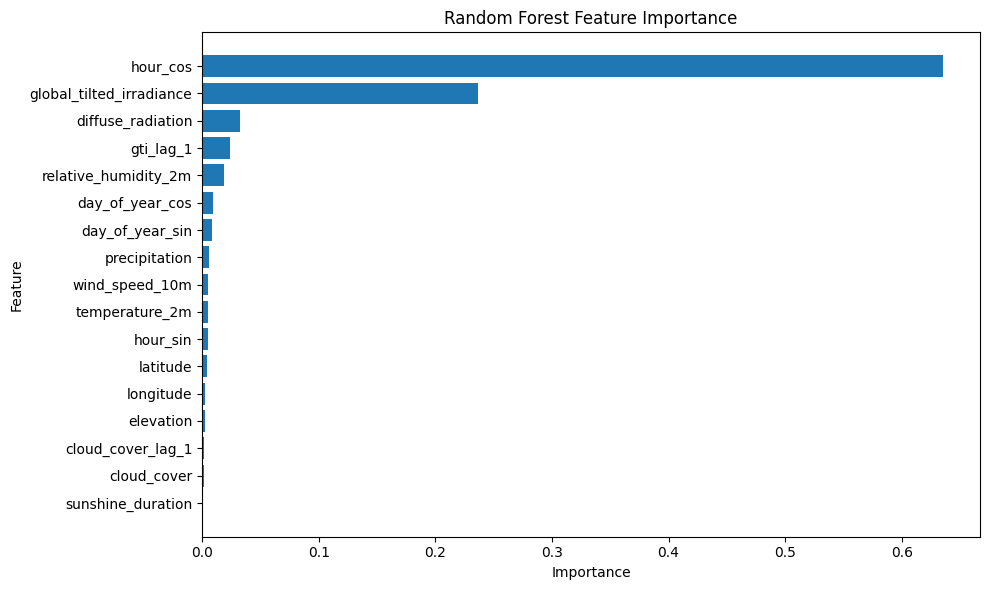

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../Figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SHAP Analysis

In [21]:
import shap

Prepare Shap Sample

In [22]:
X_shap = X_test.sample(
    n=500,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 17)


Calculate SHAP Values

In [23]:
explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_shap
)

print(
    "SHAP values shape:",
    shap_values.shape
)

SHAP values shape: (500, 17)


SHAP Feature Importance

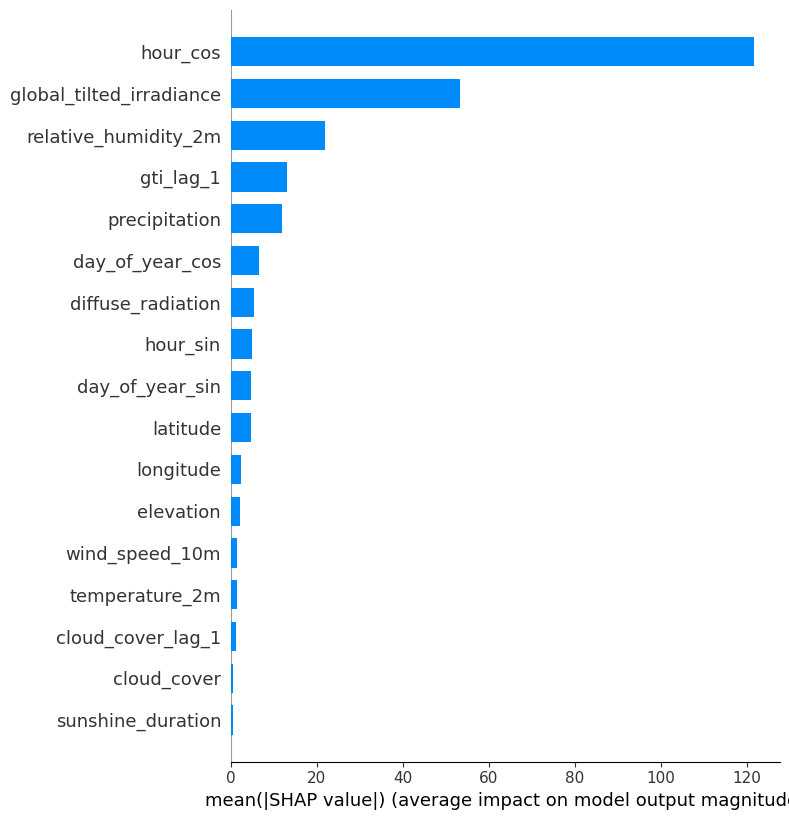

In [32]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Figures/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SHAP Summary Plot

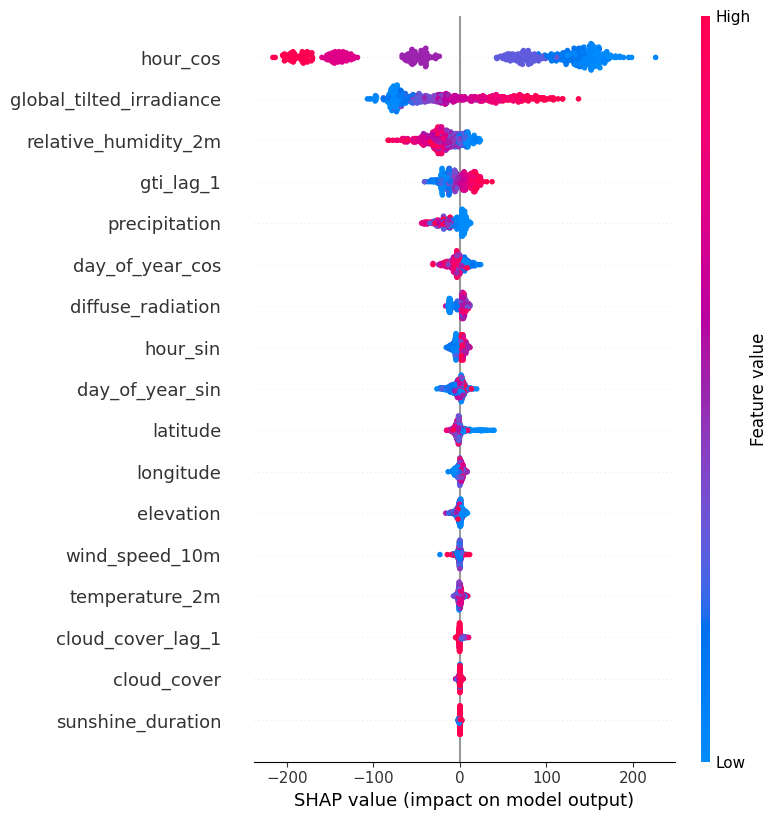

In [33]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Figures/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 SHAP Results

In [26]:
np.save(
    "../Models/shap_values.npy",
    shap_values
)

X_shap.to_csv(
    "../Models/shap_sample.csv",
    index=False
)

print("SHAP results saved.")

SHAP results saved.
